# Margin Classification

This notebook connects geometric margin, soft-margin regularization, feature
maps, kernels, multiclass reductions, and held-out evaluation. It follows ISLP
Chapter 9 while keeping the model, loss, and evaluation claim separate.

In [1]:
# Colab opens this notebook on its own, so fetch the data files that sit
# beside it in the course repository. Running locally, this does nothing.
from pathlib import Path as _Path
import urllib.request as _req
_RAW = 'https://raw.githubusercontent.com/ZhuoranYang/sds265-fall26/main/demos/09-margin-classification/'
for _name in ['Heart.csv']:
    if not _Path(_name).exists():
        _req.urlretrieve(_RAW + _name, _name)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.datasets import make_blobs, make_circles
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

SEED = 26510
rng = np.random.default_rng(SEED)

## Maximum margin and support vectors

support-vector indices: [ 7  6 33]
training accuracy: 1.0


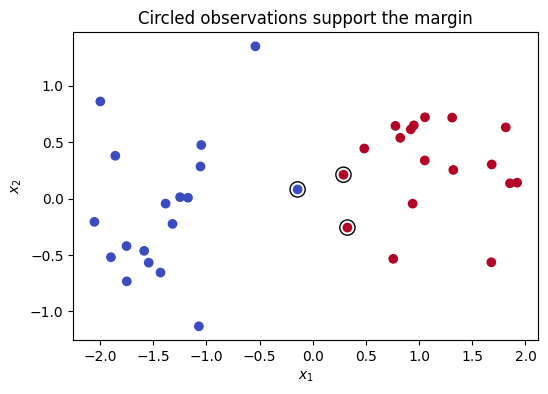

In [2]:
X, y01 = make_blobs(n_samples=36,
                    centers=[(-1.25, -0.15), (1.20, 0.35)],
                    cluster_std=[0.52, 0.50],
                    random_state=SEED)
y = 2*y01 - 1
hard = SVC(kernel='linear', C=1e5).fit(X, y)
print('support-vector indices:', hard.support_)
print('training accuracy:', hard.score(X, y))

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm')
plt.scatter(hard.support_vectors_[:, 0], hard.support_vectors_[:, 1],
            s=120, facecolors='none', edgecolors='black')
plt.title('Circled observations support the margin')
plt.xlabel('$x_1$'); plt.ylabel('$x_2$');

## Soft margin and the parameter C

In [3]:
X_soft, y01_soft = make_blobs(n_samples=70,
                              centers=[(-0.75, -0.10), (0.85, 0.20)],
                              cluster_std=[0.92, 0.90],
                              random_state=SEED + 1)
y_soft = 2*y01_soft - 1

for C in [0.08, 1, 50]:
    model = SVC(kernel='linear', C=C).fit(X_soft, y_soft)
    signed_margin = y_soft * model.decision_function(X_soft)
    print({'C': C,
           'training accuracy': model.score(X_soft, y_soft),
           'support vectors': len(model.support_),
           'margin violations': int(np.sum(signed_margin < 1))})

{'C': 0.08, 'training accuracy': 0.7428571428571429, 'support vectors': 52, 'margin violations': 51}
{'C': 1, 'training accuracy': 0.7285714285714285, 'support vectors': 44, 'margin violations': 43}
{'C': 50, 'training accuracy': 0.7285714285714285, 'support vectors': 42, 'margin violations': 41}


## Feature maps and kernel boundaries

In [4]:
X_circle, y01_circle = make_circles(n_samples=220, factor=.42,
                                    noise=.07, random_state=SEED + 2)
train, test = train_test_split(np.arange(len(X_circle)), test_size=.35,
                               random_state=SEED, stratify=y01_circle)
models = {
    'linear': SVC(kernel='linear', C=1),
    'polynomial degree 2': SVC(kernel='poly', degree=2, coef0=1, gamma=1, C=1),
    'RBF': SVC(kernel='rbf', gamma=2, C=1),
}
for name, model in models.items():
    model.fit(X_circle[train], y01_circle[train])
    print(name, 'train=', model.score(X_circle[train], y01_circle[train]),
          'test=', model.score(X_circle[test], y01_circle[test]))

linear train= 0.6083916083916084 test= 0.4935064935064935
polynomial degree 2 train= 1.0 test= 1.0
RBF train= 1.0 test= 1.0


## Multiclass OVA and OVO

In [5]:
X_multi, y_multi = make_blobs(n_samples=320,
                              centers=[(-1.6,-.8), (1.5,-.65),
                                       (0,1.55), (0,-2.0)],
                              cluster_std=.65, random_state=SEED + 3)
Xtr, Xte, ytr, yte = train_test_split(
    X_multi, y_multi, test_size=.35, random_state=SEED, stratify=y_multi)

models = {
    'OVA': OneVsRestClassifier(SVC(kernel='linear', C=1)),
    'OVO': OneVsOneClassifier(SVC(kernel='linear', C=1)),
}
for name, model in models.items():
    model.fit(Xtr, ytr)
    print(name, 'binary fits=', len(model.estimators_),
          'test accuracy=', accuracy_score(yte, model.predict(Xte)))

OVA binary fits= 4 test accuracy= 0.9642857142857143
OVO binary fits= 6 test accuracy= 0.9285714285714286


## Heart data: a realistic mixed-feature pipeline

In [6]:
heart = pd.read_csv('Heart.csv').drop(columns=['Unnamed: 0'])
target = (heart.pop('AHD') == 'Yes').astype(int)
categorical = heart.select_dtypes('object').columns.tolist()
numeric = [c for c in heart.columns if c not in categorical]

preprocess = ColumnTransformer([
    ('numeric', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), numeric),
    ('categorical', make_pipeline(SimpleImputer(strategy='most_frequent'),
                                  OneHotEncoder(handle_unknown='ignore')), categorical),
])
model = make_pipeline(preprocess, SVC(kernel='linear', C=1))
Xtr, Xte, ytr, yte = train_test_split(
    heart, target, test_size=.30, random_state=SEED, stratify=target)
model.fit(Xtr, ytr)
prediction = model.predict(Xte)
print('test accuracy:', accuracy_score(yte, prediction))
print(confusion_matrix(yte, prediction))

test accuracy: 0.8351648351648352
[[43  6]
 [ 9 33]]


## Part 2 --- every figure in the slides

These cells are the code that produced the figures in the deck, with each file write replaced by an inline plot.

In [7]:
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# The course palette and figure sizes, copied from slides/figures/sds265_style.py
BLUE, BLUE_BRIGHT, RED, GREEN = '#00356B', '#286DC0', '#7A3E47', '#5B7864'
INK, MUTED, RULE, BLUE_PALE = '#202A35', '#66727E', '#D8E0E8', '#F2F6FA'
BLUE_FILL, RED_FILL, GREEN_FILL = '#7B8FA3', '#A3838A', '#8FA394'
CYCLE = [BLUE, RED, GREEN, BLUE_BRIGHT, MUTED]
TEXTWIDTH, TEXTHEIGHT = 5.63, 3.09
FULL, FULL_TALL, FULL_SHORT = (TEXTWIDTH, 2.0), (TEXTWIDTH, 2.35), (TEXTWIDTH, 1.7)
HALF, HALF_TALL = (2.70, 2.05), (2.70, 2.45)

def use_course_style():
    mpl.rcParams.update({'figure.dpi': 130, 'font.size': 9, 'axes.titlecolor': BLUE,
                         'axes.edgecolor': MUTED, 'axes.linewidth': .7,
                         'axes.spines.top': False, 'axes.spines.right': False,
                         'xtick.color': MUTED, 'ytick.color': MUTED,
                         'legend.frameon': False, 'lines.linewidth': 1.8,
                         'axes.prop_cycle': mpl.cycler(color=CYCLE)})

def save(fig, *paths):     # the deck writes files; the notebook shows the plot
    plt.show()
    return Path(paths[0]) if paths else Path('figure.pdf')

use_course_style()
# The figure scripts locate the data through OUT.parents[2]; point OUT at the
# directory the deck uses because figure names are derived from it.
COURSE = Path.cwd().parents[1]
OUT = COURSE / 'slides' / 'figures' / '09-margin-classification'
NOTES = COURSE / 'lectures' / 'figures'

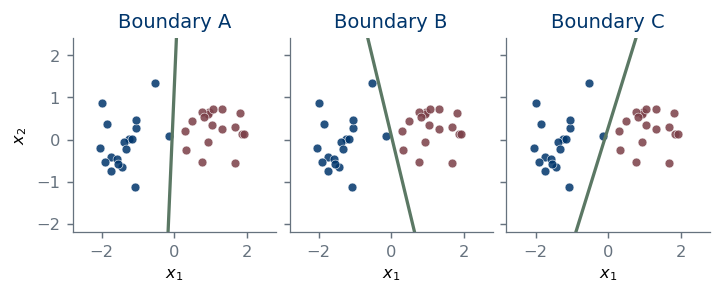

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/separating-hyperplanes.pdf')

In [8]:
from __future__ import annotations


import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs, make_circles
from sklearn.svm import SVC





SEED = 26510
rng = np.random.default_rng(SEED)


def scatter_binary(ax, X, y, *, alpha=0.85):
    ax.scatter(
        X[y == -1, 0],
        X[y == -1, 1],
        s=24,
        color=BLUE,
        alpha=alpha,
        edgecolors="white",
        linewidths=0.35,
    )
    ax.scatter(
        X[y == 1, 0],
        X[y == 1, 1],
        s=24,
        color=RED,
        alpha=alpha,
        edgecolors="white",
        linewidths=0.35,
    )


def line_from_score(ax, w, b, *, level=0, color=GREEN, style="-", width=1.8):
    xs = np.array(ax.get_xlim())
    if abs(w[1]) < 1e-8:
        x_value = (level - b) / w[0]
        ax.axvline(x_value, color=color, linestyle=style, linewidth=width)
    else:
        ys = -(w[0] * xs + b - level) / w[1]
        ax.plot(xs, ys, color=color, linestyle=style, linewidth=width)


def svc_panel(ax, X, y, model, title, *, support=True):
    scatter_binary(ax, X, y)
    gx, gy = np.meshgrid(
        np.linspace(X[:, 0].min() - 0.8, X[:, 0].max() + 0.8, 260),
        np.linspace(X[:, 1].min() - 0.8, X[:, 1].max() + 0.8, 260),
    )
    grid = np.column_stack([gx.ravel(), gy.ravel()])
    score = model.decision_function(grid).reshape(gx.shape)
    ax.contourf(
        gx,
        gy,
        score,
        levels=[-1e9, 0, 1e9],
        colors=[BLUE_PALE, "#F8F1F2"],
        alpha=0.72,
    )
    levels = [-1, 0, 1] if score.min() <= -1 and score.max() >= 1 else [0]
    styles = ["--", "-", "--"] if len(levels) == 3 else ["-"]
    widths = [1.0, 1.8, 1.0] if len(levels) == 3 else [1.8]
    ax.contour(
        gx,
        gy,
        score,
        levels=levels,
        colors=[GREEN] * len(levels),
        linestyles=styles,
        linewidths=widths,
    )
    if support and hasattr(model, "support_vectors_"):
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=62,
            facecolors="none",
            edgecolors=MUTED,
            linewidths=1.1,
        )
    ax.set(title=title, xlabel="$x_1$", ylabel="$x_2$")


# A fixed separable dataset used for the opening geometry.
X_sep, y01_sep = make_blobs(
    n_samples=36,
    centers=[(-1.25, -0.15), (1.20, 0.35)],
    cluster_std=[0.52, 0.50],
    random_state=SEED,
)
y_sep = 2 * y01_sep - 1


# Several zero-training-error hyperplanes.
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
candidates = [
    (np.array([1.0, -0.05]), 0.06),
    (np.array([1.0, 0.28]), -0.03),
    (np.array([1.0, -0.36]), 0.10),
]
for ax, (w, b), title in zip(axes, candidates, ["Boundary A", "Boundary B", "Boundary C"]):
    scatter_binary(ax, X_sep, y_sep)
    ax.set(xlim=(-2.8, 2.8), ylim=(-2.2, 2.4), title=title, xlabel="$x_1$")
    line_from_score(ax, w, b)
axes[0].set_ylabel("$x_2$")
fig.tight_layout(w_pad=0.45)
save(fig, OUT / "separating-hyperplanes.pdf", OUT / "separating-hyperplanes.svg")

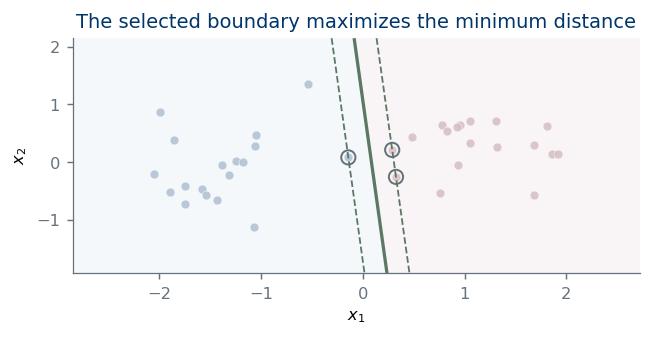

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/max-margin.pdf')

In [9]:
# Selected maximum-margin boundary.
hard = SVC(kernel="linear", C=1e5)
hard.fit(X_sep, y_sep)
fig, ax = plt.subplots(figsize=FULL_TALL)
svc_panel(ax, X_sep, y_sep, hard, "The selected boundary maximizes the minimum distance")
save(fig, OUT / "max-margin.pdf", OUT / "max-margin.svg")

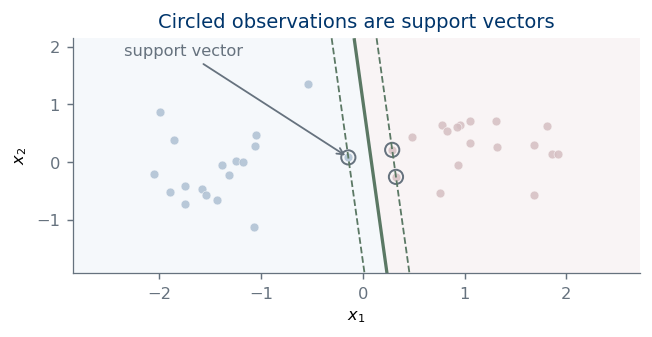

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/support-vectors.pdf')

In [10]:
# Make the supporting observations explicit.
fig, ax = plt.subplots(figsize=FULL_TALL)
svc_panel(ax, X_sep, y_sep, hard, "Circled observations are support vectors")
ax.annotate(
    "support vector",
    hard.support_vectors_[0],
    xytext=(-2.35, 1.85),
    arrowprops={"arrowstyle": "->", "color": MUTED},
    color=MUTED,
)
save(fig, OUT / "support-vectors.pdf", OUT / "support-vectors.svg")

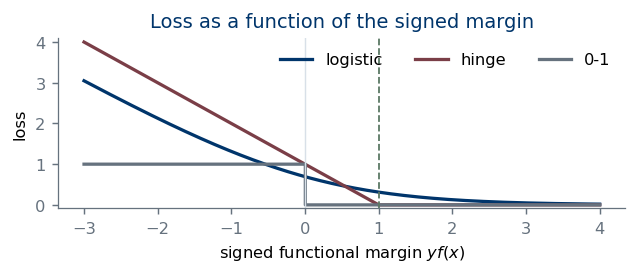

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/loss-comparison.pdf')

In [11]:
# Margin loss comparison.
margin = np.linspace(-3, 4, 700)
logistic = np.logaddexp(0, -margin)
hinge = np.maximum(0, 1 - margin)
zero_one = (margin <= 0).astype(float)
fig, ax = plt.subplots(figsize=FULL_SHORT)
ax.plot(margin, logistic, color=BLUE, label="logistic")
ax.plot(margin, hinge, color=RED, label="hinge")
ax.step(margin, zero_one, color=MUTED, where="post", label="0-1")
ax.axvline(0, color=RULE, linewidth=0.8)
ax.axvline(1, color=GREEN, linestyle="--", linewidth=1.0)
ax.set(
    xlabel="signed functional margin $y f(x)$",
    ylabel="loss",
    ylim=(-0.08, 4.1),
    title="Loss as a function of the signed margin",
)
ax.legend(ncol=3)
save(fig, OUT / "loss-comparison.pdf", OUT / "loss-comparison.svg")

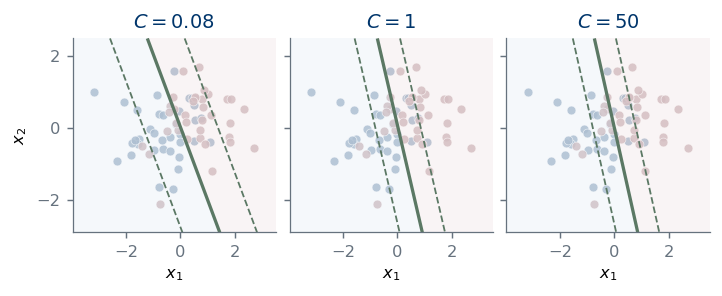

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/soft-margin-sequence.pdf')

In [12]:
# Soft-margin sequence on a nonseparable sample.
X_soft, y01_soft = make_blobs(
    n_samples=70,
    centers=[(-0.75, -0.10), (0.85, 0.20)],
    cluster_std=[0.92, 0.90],
    random_state=SEED + 1,
)
y_soft = 2 * y01_soft - 1
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
for ax, C in zip(axes, [0.08, 1.0, 50.0]):
    model = SVC(kernel="linear", C=C)
    model.fit(X_soft, y_soft)
    svc_panel(ax, X_soft, y_soft, model, f"$C={C:g}$", support=False)
    ax.set_ylabel("")
axes[0].set_ylabel("$x_2$")
fig.tight_layout(w_pad=0.45)
save(fig, OUT / "soft-margin-sequence.pdf", OUT / "soft-margin-sequence.svg")

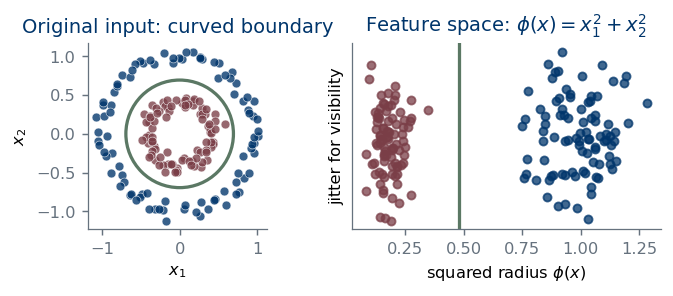

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/feature-map-boundary.pdf')

In [13]:
# A nonlinear feature that makes radius linearly separable.
X_circle, y01_circle = make_circles(
    n_samples=180,
    factor=0.42,
    noise=0.055,
    random_state=SEED + 2,
)
y_circle = 2 * y01_circle - 1
radius2 = np.sum(X_circle**2, axis=1)
threshold = 0.48
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL)
scatter_binary(axes[0], X_circle, y_circle, alpha=0.78)
circle = plt.Circle((0, 0), np.sqrt(threshold), fill=False, color=GREEN, linewidth=1.8)
axes[0].add_patch(circle)
axes[0].set(
    title="Original input: curved boundary",
    xlabel="$x_1$",
    ylabel="$x_2$",
    aspect="equal",
)
jitter = rng.normal(0, 0.025, len(radius2))
axes[1].scatter(radius2[y_circle == -1], jitter[y_circle == -1], s=20, color=BLUE, alpha=0.75)
axes[1].scatter(radius2[y_circle == 1], jitter[y_circle == 1], s=20, color=RED, alpha=0.75)
axes[1].axvline(threshold, color=GREEN, linewidth=1.8)
axes[1].set(
    title=r"Feature space: $\phi(x)=x_1^2+x_2^2$",
    xlabel=r"squared radius $\phi(x)$",
    ylabel="jitter for visibility",
    yticks=[],
)
fig.tight_layout(w_pad=0.85)
save(fig, OUT / "feature-map-boundary.pdf", OUT / "feature-map-boundary.svg")

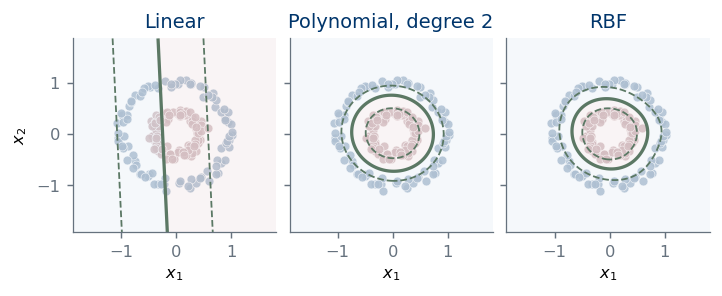

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/kernel-boundaries.pdf')

In [14]:
# Kernel comparison.
fig, axes = plt.subplots(1, 3, figsize=FULL_TALL, sharex=True, sharey=True)
models = [
    ("Linear", SVC(kernel="linear", C=1)),
    ("Polynomial, degree 2", SVC(kernel="poly", degree=2, coef0=1, gamma=1, C=1)),
    ("RBF", SVC(kernel="rbf", gamma=2, C=1)),
]
for ax, (title, model) in zip(axes, models):
    model.fit(X_circle, y_circle)
    svc_panel(ax, X_circle, y_circle, model, title, support=False)
    ax.set_ylabel("")
axes[0].set_ylabel("$x_2$")
fig.tight_layout(w_pad=0.45)
save(fig, OUT / "kernel-boundaries.pdf", OUT / "kernel-boundaries.svg")

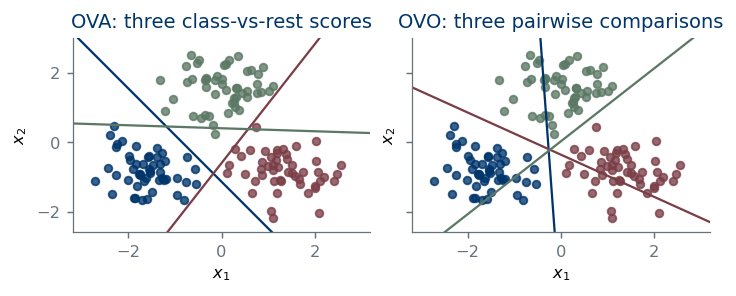

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/multiclass-reductions.pdf')

In [15]:
# Multiclass reductions.
X_multi, y_multi = make_blobs(
    n_samples=150,
    centers=[(-1.6, -0.8), (1.5, -0.65), (0.0, 1.55)],
    cluster_std=0.55,
    random_state=SEED + 3,
)
colors = [BLUE, RED, GREEN]
fig, axes = plt.subplots(1, 2, figsize=FULL_TALL, sharex=True, sharey=True)
for ax in axes:
    for k, color in enumerate(colors):
        ax.scatter(X_multi[y_multi == k, 0], X_multi[y_multi == k, 1], s=18, color=color, alpha=0.78)
    ax.set(xlabel="$x_1$", ylabel="$x_2$")
    ax.set(xlim=(-3.2, 3.2), ylim=(-2.6, 3.0))
axes[0].set_title("OVA: three class-vs-rest scores")
for k, color in enumerate(colors):
    model = SVC(kernel="linear", C=10).fit(X_multi, np.where(y_multi == k, 1, -1))
    line_from_score(axes[0], model.coef_[0], model.intercept_[0], color=color, width=1.25)
axes[1].set_title("OVO: three pairwise comparisons")
for a, b, color in [(0, 1, BLUE), (0, 2, RED), (1, 2, GREEN)]:
    use = np.isin(y_multi, [a, b])
    model = SVC(kernel="linear", C=10).fit(X_multi[use], y_multi[use])
    line_from_score(axes[1], model.coef_[0], model.intercept_[0], color=color, width=1.25)
fig.tight_layout(w_pad=0.75)
save(fig, OUT / "multiclass-reductions.pdf", OUT / "multiclass-reductions.svg")

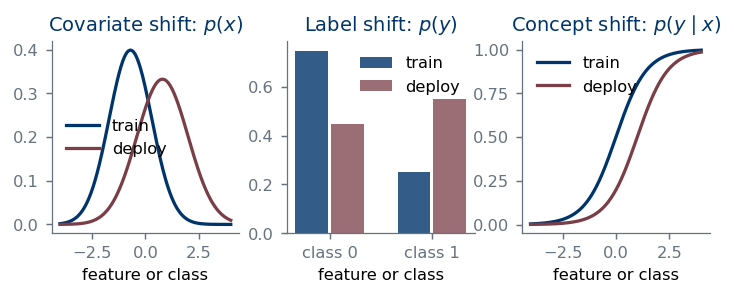

PosixPath('/Users/zhuoran_cisco/Dropbox/zhuoran_teaching/zhuoran-yale-teaching/SDS265/slides/figures/09-margin-classification/distribution-shift.pdf')

In [16]:
# Three stylized types of distribution shift.
x = np.linspace(-4, 4, 500)


def normal(mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (sigma * np.sqrt(2 * np.pi))


fig, axes = plt.subplots(1, 3, figsize=FULL_TALL)
axes[0].plot(x, normal(-0.7, 1), color=BLUE, label="train")
axes[0].plot(x, normal(0.8, 1.2), color=RED, label="deploy")
axes[0].set_title("Covariate shift: $p(x)$")
axes[1].bar([0, 1], [0.75, 0.25], width=0.32, color=BLUE, alpha=0.8, label="train")
axes[1].bar([0.35, 1.35], [0.45, 0.55], width=0.32, color=RED, alpha=0.75, label="deploy")
axes[1].set_xticks([0.175, 1.175], ["class 0", "class 1"])
axes[1].set_title("Label shift: $p(y)$")
axes[2].plot(x, 1 / (1 + np.exp(-1.4 * x)), color=BLUE, label="train")
axes[2].plot(x, 1 / (1 + np.exp(-1.4 * (x - 1.0))), color=RED, label="deploy")
axes[2].set_title("Concept shift: $p(y\\mid x)$")
for ax in axes:
    ax.legend()
    ax.set_xlabel("feature or class")
fig.tight_layout(w_pad=0.55)
save(fig, OUT / "distribution-shift.pdf", OUT / "distribution-shift.svg")

In [17]:
print(f"Separable sample: n={len(X_sep)}, support vectors={len(hard.support_)}")
print(f"Circle sample: n={len(X_circle)}")

Separable sample: n=36, support vectors=3
Circle sample: n=180
